In [183]:
include("CRD_STA.jl")
include("LST_BEK.jl")
import .CRD_BF as BF
using Plots
using LinearAlgebra
using ProgressMeter
using NonlinearEigenproblems

In [87]:
function rayleigh_quotient_iteration(A, B, sigma; q0=rand(size(A, 1), 1))

    flg = true
    while flg
        sigma0 = sigma[1]+ 0.0e0im
        q = (A - sigma*B) \ (B*q0)
        q0 = q/maximum(abs.(q))
        sigma = ((q0'*(A*q0))/(q0'*(B*q0)))[1]
        if abs(sigma-sigma0)<=eps(1.0f0)
            flg = false
        end

    end

      return sigma, q0
    end

rayleigh_quotient_iteration (generic function with 1 method)

In [86]:
function select(values,val,v1)
    index=findall(x->x==values,val)
    vec = v1[:,index]
    u = vec[1:N_cheb-1,1]
    v = vec[N_cheb:2*(N_cheb-1),1]
    return vec,u,v
end

select (generic function with 1 method)

In [200]:
N_cheb = 99
Re = 285.36
R = sqrt(Re)
Mr = 0.1
Ma = Mr/Re
Tw = 1
gamma = 1.4
sigma = 0.72
be = 0.07759
omega = 0
F,G,W,f,q,D,D2,x,t,PHI = baseflow_var(N_cheb)
rho,H,T,T_x,rho_x = T_ca(Re,Ma,f,q,W,gamma,Tw,x,t,N_cheb)
lam = - (2/3) * T
kappa = (1/sigma) * T ;

In [206]:
C0,C1,C2,C3,C4 = KEB_SpatialMode.KEB_LST_ALL("Vonkarmen.txt",N_cheb,omega,be,Re,1,2)
nep = PEP([C0,C1,C2,C3,C4]); #Create a PEP object
sc=10
nep1 = shift_and_scale(nep,scale=sc);
mult_scale = norm(nep1.A[end]);
nep2 = PEP(nep1.A ./ mult_scale);
λ1,v1 = iar(nep2,σ=0.01,neigs=50,maxit=500);
λ_orig = sc*λ1
point = filter(x -> -0.001 < imag(x) < 0.001, λ_orig)
# vec = select(point,λ_orig,v1)

1-element Vector{ComplexF64}:
 0.3849581024846824 + 7.635477955572062e-5im

In [ ]:
index = findall(x->x == point[1] , λ_orig)
vec = v1[:,index]
f,g,h = eigvec_compute.compute(vec,N_cheb,al,be,R,D)

In [ ]:
plot(x,imag(g),xlims=[0,12])

In [202]:
A0,A1,A2 = Spatial_mode(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be)
nep = PEP([A0,A1,A2]); 
sc=10
nep1 = shift_and_scale(nep,scale=sc);
mult_scale = norm(nep1.A[end]);
nep2 = PEP(nep1.A ./ mult_scale);
λ1,v1 = iar(nep2,σ = 0.01,neigs = 30,maxit = 500);
λ_orig = λ1 * sc
point = filter(x -> -0.02 < imag(x) < 0, λ_orig)

ComplexF64[]

In [ ]:
vec,u,v = select(point[1],λ_orig,v1)

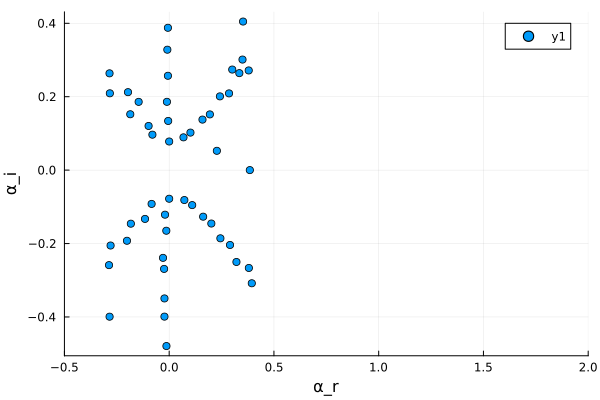

In [207]:
scatter(real(λ_orig),imag(λ_orig),xlim=[-0.5,2],xlabel="α_r",ylabel="α_i")